# Medusa Full Python Port

This notebook demonstrates:
1. Full parameter lifting port (`mate_interact` logic)
2. Plane/sphere rendering port (`drawpullback` + `draw_pb_sphere`)
3. Comparison against legacy C++ output files


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "python").exists() and (REPO_ROOT.parent / "python").exists():
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "python"))

from medusa_full import compute_parameter_sequence, write_param_file
from medusa_modern import (
    read_param_file,
    render_plane_pullback,
    render_sphere_pullback,
    plot_parameter_trajectory,
    plot_plane_pullback,
    plot_sphere_pullback,
    save_figure,
)

plt.rcParams["figure.dpi"] = 120

## 1) Compute Parameters with Full-Port Engine

In [2]:
p1, q1, p2, q2 = 1, 7, 3, 7

# strict mode: stop when iterate reports failure
# compat mode: continue for requested count (closer to mate_interact loop behavior)
a_strict, b_strict = compute_parameter_sequence(p1, q1, p2, q2, iterations=35, stop_on_failure=True)
a_compat, b_compat = compute_parameter_sequence(p1, q1, p2, q2, iterations=35, stop_on_failure=False)

print("Strict length:", len(a_strict))
print("Compat length:", len(a_compat))
print("First strict (a,b):", a_strict[0], b_strict[0])

Strict length: 6
Compat length: 35
First strict (a,b): (0.321283110742684+0.4291932316740698j) (-0.07300602903712754-0.3720012814573276j)


## 2) Compare Strict Prefix with C++ Output

In [3]:
a_cpp, b_cpp = read_param_file(REPO_ROOT / "output" / "m17v37.txt")

n = min(len(a_cpp), len(a_strict))
max_da = np.max(np.abs(a_cpp[:n] - a_strict[:n])) if n else np.nan
max_db = np.max(np.abs(b_cpp[:n] - b_strict[:n])) if n else np.nan

print("Compared entries:", n)
print("max |a_cpp - a_strict| over overlap:", max_da)
print("max |b_cpp - b_strict| over overlap:", max_db)

Compared entries: 6
max |a_cpp - a_strict| over overlap: 4.853056814110107e-07
max |b_cpp - b_strict| over overlap: 4.2677441263209486e-07


## 3) Write Python Parameter File (Compat Mode)

In [4]:
out_param = REPO_ROOT / "output_py" / "param_py_m17v37.txt"
out_param.parent.mkdir(parents=True, exist_ok=True)
write_param_file(out_param, a_compat, b_compat)
print("Wrote:", out_param)

Wrote: /mnt/c/Users/vittu/src/Medusa/output_py/param_py_m17v37.txt


## 4) Render Plane and Sphere from Python-Generated Parameters

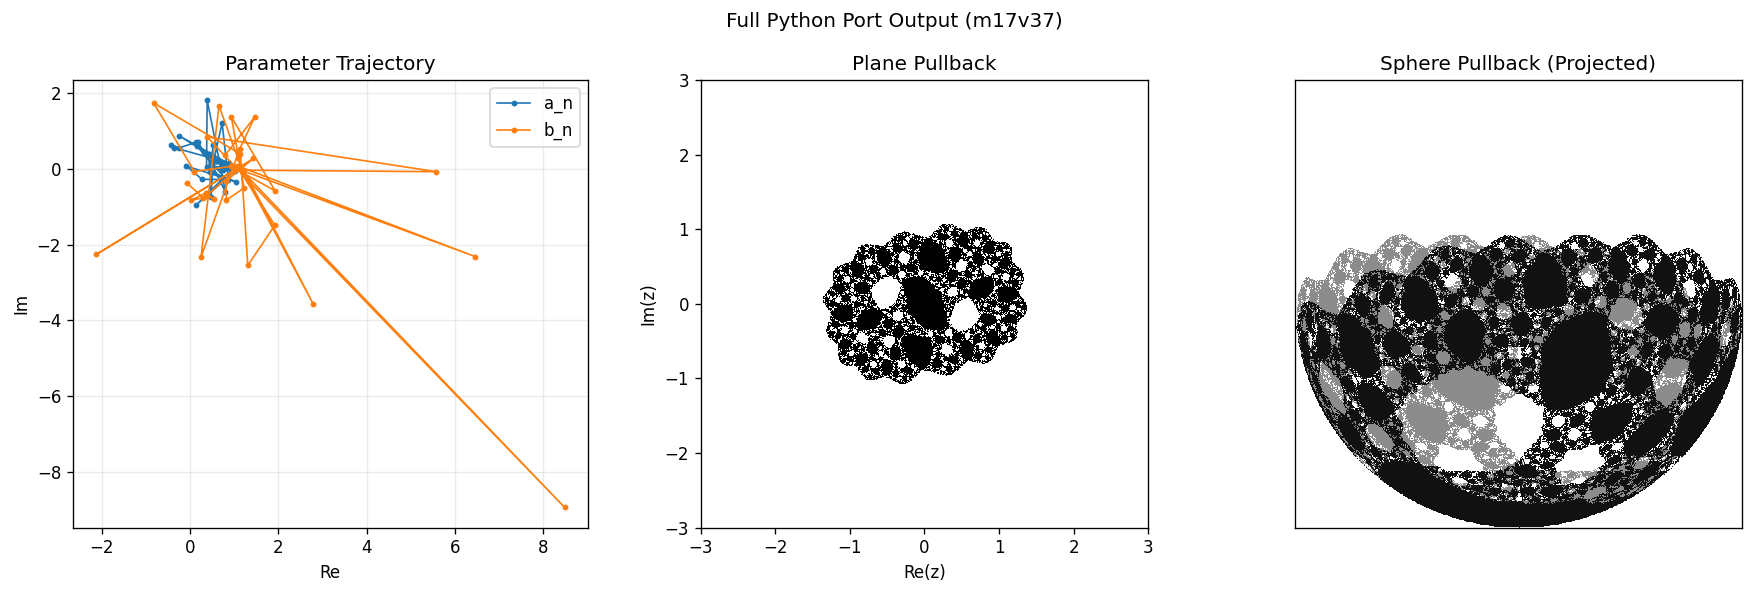

In [5]:
plane = render_plane_pullback(a_compat, b_compat, bounds=(-3, 3, -3, 3), dpi=96)
sphere = render_sphere_pullback(a_compat, b_compat, dpi=96)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_parameter_trajectory(a_compat, b_compat, ax=axes[0])
plot_plane_pullback(plane, ax=axes[1])
plot_sphere_pullback(sphere, ax=axes[2])
fig.suptitle("Full Python Port Output (m17v37)")
fig.tight_layout()
plt.show()

## 5) Save Combined Figure

Saved to /mnt/c/Users/vittu/src/Medusa/output_py


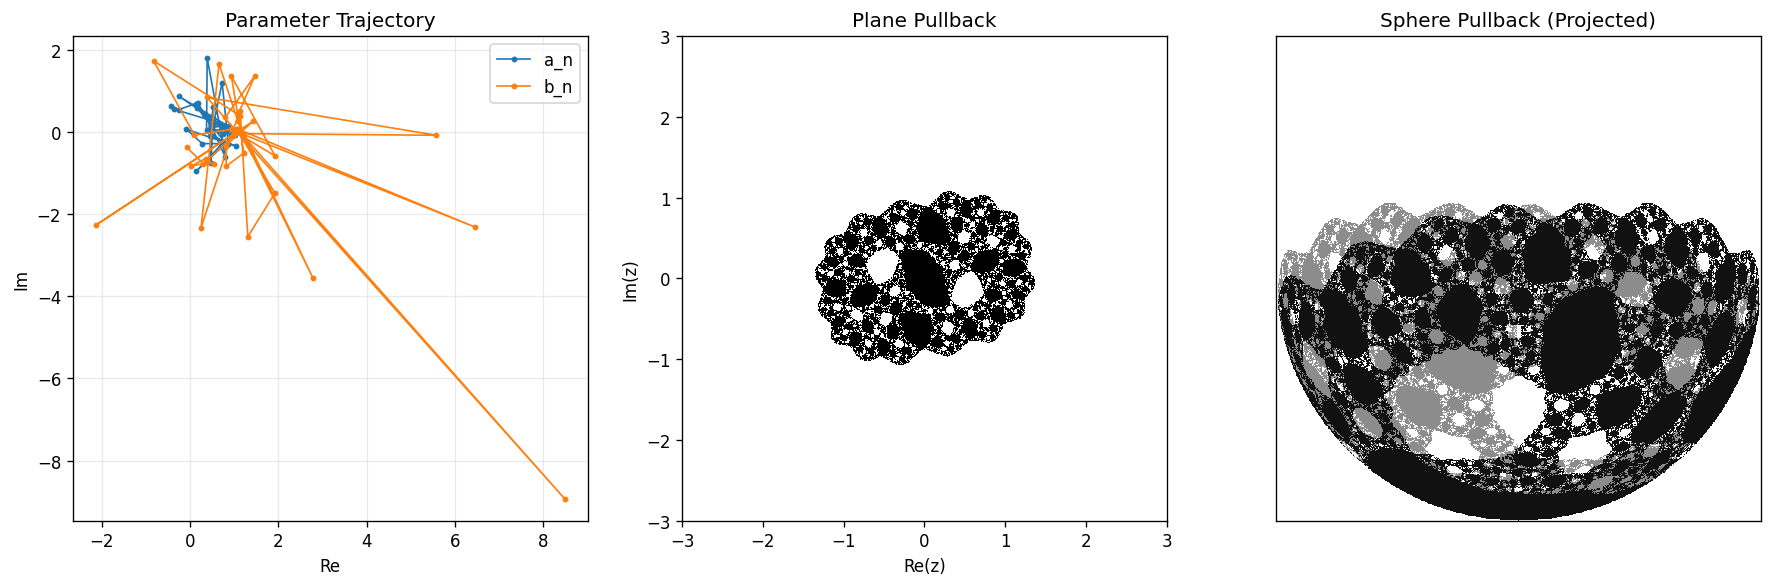

In [6]:
out_dir = REPO_ROOT / "output_py"
out_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_parameter_trajectory(a_compat, b_compat, ax=axes[0])
plot_plane_pullback(plane, ax=axes[1])
plot_sphere_pullback(sphere, ax=axes[2])
fig.tight_layout()

save_figure(fig, out_dir / "full_port_notebook_overview.png")
save_figure(fig, out_dir / "full_port_notebook_overview.pdf")
print("Saved to", out_dir)